## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué performance presentan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Carga datos y representa la serie

In [2]:
df = pd.read_csv("./data/AirPassengers.csv", parse_dates=["date"], index_col=["date"])

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [4]:
df.head(20)

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [7]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

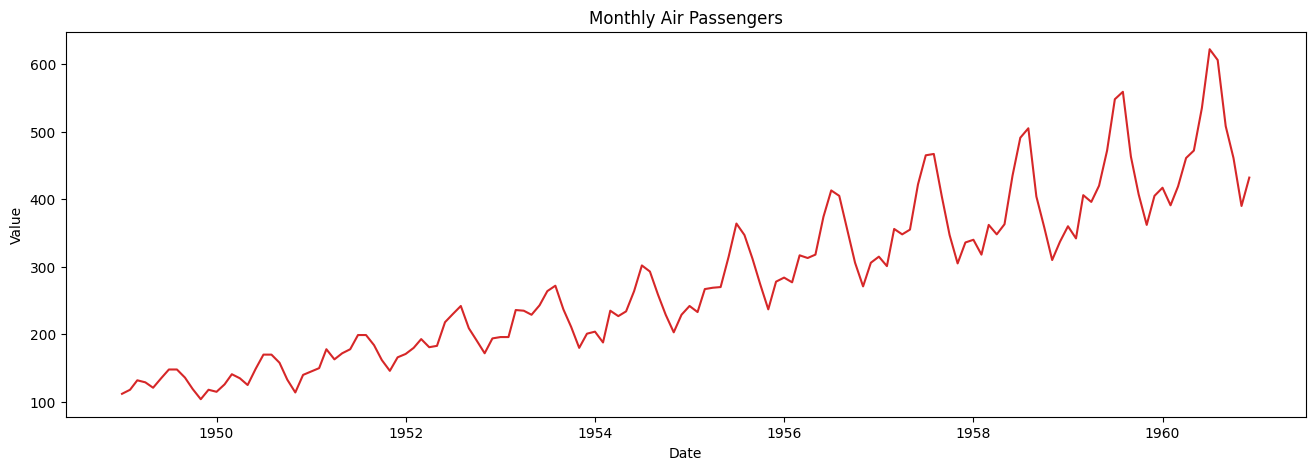

In [8]:
plot_df(df, x=df.index, y=df["value"], title="Monthly Air Passengers")

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

In [10]:
result_mul = seasonal_decompose(df["value"], model = "multiplicative", extrapolate_trend = "freq")

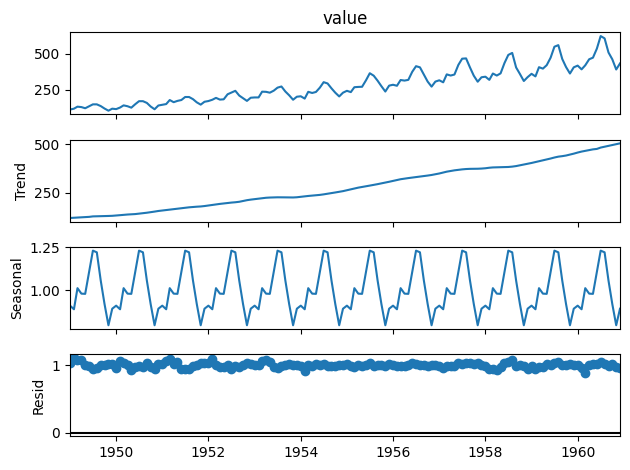

In [11]:
result_mul.plot();

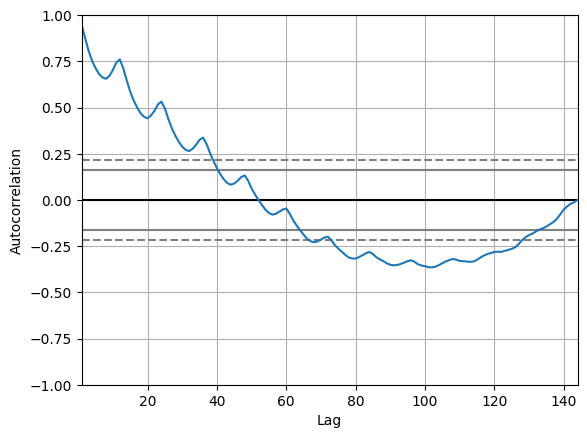

In [12]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df["value"]);

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior

In [15]:
def plot_df(df, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    # plt.figure(figsize=(6,5), dpi=dpi)
    
    rolling_mean = df[y].rolling(window=12, center= True).mean()
    
    plt.plot(df.index, df[y], color='tab:red', label='Original')
    plt.plot(df.index, rolling_mean, color='blue', label='Rolling Mean (12)', )
    
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    # plt.xticks(df.index[::12], rotation=45)
    plt.tight_layout()
    plt.show()

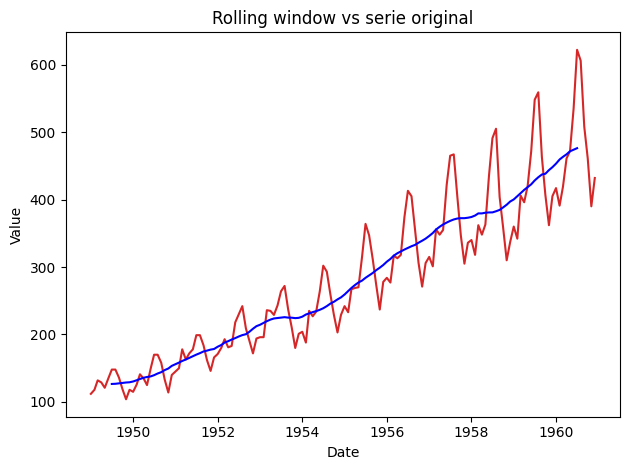

In [16]:
plot_df(df, y="value", title="Rolling window vs serie original")

## 3. Comprueba de manera estadística si la serie es o no stationary.

El test estadístico es positivo, lo cual implica que es mucho menos probable que rechacemos la hipótesis nula (no estacionaria).

Al comparar el estadístico ADF con los valores críticos, parece que no podríamos rechazar la hipótesis nula de que la serie temporal no es estacionaria y en consecuencia afirmamos que la serie tiene una estructura que sí que es dependiente del tiempo.

Un valor p por encima del umbral sugiere que no rechazamos la hipótesis nula (no estacionario).

In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
print(f"ADF Statistic: {adfuller(df["value"])[0]}")
print(f"p-value: {adfuller(df["value"])[1]}")
print(f"Critical Values: \n {adfuller(df["value"])[4]}")

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Critical Values: 
 {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


## 4. Aplica una transformación logarítmica

Podemos ver que el valor es mayor que los valores críticos, lo que significa que podemos rechazar la hipótesis nula y, a su vez, que la serie de tiempo no es estacionaria.

Sin embargo nos sigue interesando aplicar la transformación porque conseguimos estabilizar la varianza.

In [19]:
df["value"] = np.log1p(df["value"])

In [20]:
print(f"ADF Statistic: {adfuller(df["value"])[0]}")
print(f"p-value: {adfuller(df["value"])[1]}")
print(f"Critical Values: \n {adfuller(df["value"])[4]}")

ADF Statistic: -1.7064106124214196
p-value: 0.42781260009224653
Critical Values: 
 {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}


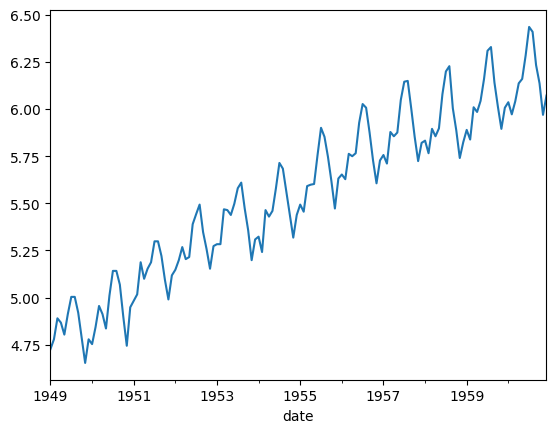

In [21]:
df["value"].plot();

## 5. Divide en train y test. Guarda 20 muestras para test.

In [23]:
train = df["value"][0:124]
test = df["value"][124:]
print(train.shape)
print(test.shape)

(124,)
(20,)


## 6. Crea tu primer modelo ARIMA

In [25]:
from pmdarima.arima import auto_arima
from pmdarima.arima import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [23]:
# import itertools
# p=d=q=range(0,5)
# pdq = list(itertools.product(p,d,q))
# pdq[:6]

In [24]:
# results = []
# for param in pdq:
#     try:
#         model_arima = ARIMA(order=param)
#         model_arima_fit = model_arima.fit(y_train)
#         results.append((param, model_arima_fit.aic()))
#     except:
#         continue

In [25]:
# resultados_df = pd.DataFrame(results, columns=["ARIMA params", "AIC"]).sort_values("AIC")
# resultados_df.head()

In [26]:
# best_model = ARIMA(order=(2, 3, 4))
# best_model.fit(y_train)

In [26]:
model = auto_arima(train,
                   start_p= 1,
                   start_q= 1,
                   max_p= 5,
                   max_q= 5,
                   max_d= 3,
                   trace=True,
                   warnings=False,
                   stationary=False,
                   error_action="ignore",
                   stepwise=True)

print(model.aic())
predictions = model.predict(20)

mse  = mean_squared_error(test.values, predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test.values, predictions)

print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-210.169, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-202.479, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-203.994, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-205.400, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-203.310, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.35 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-205.523, Time=0.14 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-226.929, Time=0.35 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-230.800, Time=0.43 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-227.851, Time=0.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-234.976, Time=0.47 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-215.964, Time=0.22 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-233.9

In [27]:
model = auto_arima(train,
                   start_p= 1,
                   start_q= 1,
                   max_p= 5,
                   max_q= 5,
                   max_d= 3,
                   m= 12,
                   trace=True,
                   warnings=False,
                   stationary=False,
                   error_action="ignore",
                   stepwise=True)

print(model.aic())
predictions = model.predict(20)

mse  = mean_squared_error(test.values, predictions)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test.values, predictions)

print(f"MSE:  {mse}")
print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=-405.503, Time=0.95 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=-291.901, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=-400.616, Time=0.64 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=-354.541, Time=0.87 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=-126.581, Time=0.03 sec
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=-412.765, Time=0.99 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=-385.379, Time=0.42 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=-410.850, Time=1.88 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=-406.436, Time=0.98 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=-407.995, Time=2.11 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=-409.267, Time=0.66 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=-411.886, Time=0.77 sec
 ARIMA(1,0,2)(0,1,1)[12] intercept   : AIC=-411.113, Time=0.98 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=-302.251, Time=0.26 sec
 ARIMA(0,0,2)(0,1,1

In [28]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  124
Model:             SARIMAX(2, 0, 0)x(0, 1, [1], 12)   Log Likelihood                 211.763
Date:                             ma., 12 may. 2026   AIC                           -413.527
Time:                                      16:37:35   BIC                           -399.934
Sample:                                  01-01-1949   HQIC                          -408.012
                                       - 04-01-1959                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0189      0.010      1.965      0.049    4.93e-05       0.038
ar.L1          0.6084      0.086      7.082      0.000       0.440       0.777
ar.L2          0.2356      0.090      2.620      0.009       0.059       0.412
ma.S.L12      -0.5624      0.116     -4.842      0.000      -0.790      -0.335
sigma2         0.0013      0.000      7.754      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 4.70
Prob(Q):                              0.98   Prob(JB):                         0.10
Heteroskedasticity (H):               0.42   Skew:                             0.09
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.99
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. Representa en una gráfica los datos de test y tus predicciones.

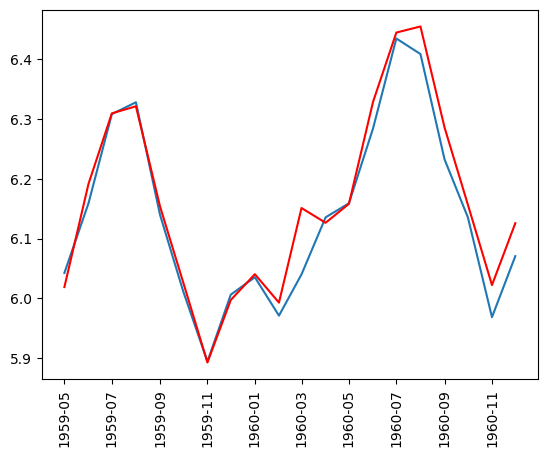

In [29]:
plt.plot(test);
plt.plot(predictions,color='red');
plt.xticks(rotation=90);

In [30]:
test

date
1959-05-01    6.042633
1959-06-01    6.159095
1959-07-01    6.308098
1959-08-01    6.327937
1959-09-01    6.139885
1959-10-01    6.011267
1959-11-01    5.894403
1959-12-01    6.006353
1960-01-01    6.035481
1960-02-01    5.971262
1960-03-01    6.040255
1960-04-01    6.135565
1960-05-01    6.159095
1960-06-01    6.284134
1960-07-01    6.434547
1960-08-01    6.408529
1960-09-01    6.232448
1960-10-01    6.135565
1960-11-01    5.968708
1960-12-01    6.070738
Name: value, dtype: float64

## 8. Prueba otros modelos, a ver qué performance presentan.

In [31]:
for i in range(12,0,-1):
    df['t-'+str(i)] = df['value'].shift(i)
df.dropna(inplace=True)

In [32]:
df.head()

,value,t-12,t-11,t-10,t-9,t-8,t-7,t-6,t-5,t-4,t-3,t-2,t-1
date,,,,,,,,,,,,,
1950-01-01,4.753590,4.727388,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123
1950-02-01,4.844187,4.779123,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590
1950-03-01,4.955827,4.890349,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187
1950-04-01,4.912655,4.867534,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827
1950-05-01,4.836282,4.804021,4.912655,5.003946,5.003946,4.919981,4.787492,4.653960,4.779123,4.753590,4.844187,4.955827,4.912655


In [33]:
X = df.iloc[:, 1:].values
Y = df.iloc[:, 1].values

X_train = X[:125-12]
X_test = X[125-12:]
y_train = Y[:125-12]
y_test = Y[125-12:]

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (113, 12)
Shape X_test: (19, 12)
Shape y_train: (113,)
Shape y_test: (19,)


In [36]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor()  # max-depth not set
tree.fit(X_train, y_train)

print("MSE:", mean_squared_error(tree.predict(X_test), y_test))
print("RMSE:", np.sqrt(mean_squared_error(tree.predict(X_test), y_test)))
print("MAE:", mean_absolute_error(tree.predict(X_test), y_test))

MSE: 0.010116914901307873
RMSE: 0.10058287578563199
MAE: 0.07606867078150904


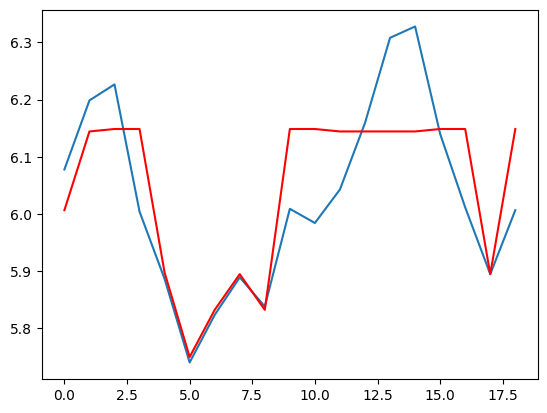

In [37]:
plt.plot(y_test);
plt.plot(tree.predict(X_test), color='red');